In [29]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv("cleaned_dataset.csv")

# Quick check
print(df.head())     # show first 5 rows



    UDI Product ID  Air temperature [K]  Process temperature [K]  \
0  1936     M16795                298.1                    307.9   
1  6495     L53674                300.6                    310.1   
2  1721     L48900                298.2                    307.7   
3  9121     L56300                297.4                    308.4   
4   361     M15220                297.5                    308.3   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                  1377.0    54.914253            108.0                0    0   
1                  1617.0    33.087783            185.0                0    0   
2                  1459.0    46.139200             89.0                0    0   
3                  1525.0    37.035995             62.0                0    0   
4                  1511.0    38.704672             74.0                0    0   

   HDF  ...  RNF  Type_H  Type_L  Type_M  Air temperature [K]_outlier  \
0    0  ...    0   False   Fals

In [30]:
print(df.info())     # check schema

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11998 entries, 0 to 11997
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   UDI                              11998 non-null  int64  
 1   Product ID                       11998 non-null  object 
 2   Air temperature [K]              11998 non-null  float64
 3   Process temperature [K]          11998 non-null  float64
 4   Rotational speed [rpm]           11998 non-null  float64
 5   Torque [Nm]                      11998 non-null  float64
 6   Tool wear [min]                  11998 non-null  float64
 7   Machine failure                  11998 non-null  int64  
 8   TWF                              11998 non-null  int64  
 9   HDF                              11998 non-null  int64  
 10  PWF                              11998 non-null  int64  
 11  OSF                              11998 non-null  int64  
 12  RNF               

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1) Build multiclass target from sub-failure flags (same as before)
sub_cols = ['TWF','HDF','PWF','OSF','RNF']
def failure_type_row(row):
    for k in sub_cols:
        if row[k] == 1:
            return k
    return "No_Failure"

df['Failure_Type'] = df.apply(failure_type_row, axis=1)

In [ ]:
# 2) Features / labels
drop_cols = ['UDI', 'Product ID', 'Machine failure'] + sub_cols + ['Failure_Type']
X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()
y_str = df['Failure_Type'].astype(str).copy()

In [ ]:
# 3) Encode labels for all models (required for XGBoost)
le = LabelEncoder()
y = le.fit_transform(y_str)          # ints 0..K-1
class_names = le.classes_.tolist()   # ['HDF','No_Failure',...]

In [ ]:
# 4) Split (STRATIFY on encoded y)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# Clean up column names for XGBoost
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train = clean_col_names(X_train)
X_test = clean_col_names(X_test)

In [ ]:
# ---- Shared evaluator (run once) ----
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(name, model, X_train, y_train, X_test, y_test, le, class_names):
    print(f"\n=== Training {name} ===")
    model.fit(X_train, y_train)
    y_pred_enc = model.predict(X_test)
    y_pred = le.inverse_transform(y_pred_enc)
    y_true = le.inverse_transform(y_test)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{name} — Accuracy: {acc:.4f} | F1_macro: {f1_macro:.4f} | F1_weighted: {f1_weighted:.4f}\n")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0, labels=class_names))

    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


In [ ]:
# Identify numeric columns (excluding the boolean type columns which were created for one hot encoding)
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Get the cleaned names of the numeric columns
num_cols_for_scale_cleaned = [clean_col_names(X_train[[col]]).columns[0] for col in num_cols]

print("Numeric columns for scaling:", num_cols_for_scale_cleaned)

Numeric columns for scaling: ['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Air_temperature_K_outlier', 'Process_temperature_K_outlier', 'Rotational_speed_rpm_outlier', 'Torque_Nm_outlier', 'Tool_wear_min_outlier', 'Speed_Torque_Ratio']



=== Training Logistic Regression ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Logistic Regression — Accuracy: 0.4029 | F1_macro: 0.1545 | F1_weighted: 0.5476

              precision    recall  f1-score   support

         HDF      0.067     0.516     0.119        31
  No_Failure      0.993     0.399     0.569      2294
         OSF      0.054     0.500     0.098        20
         PWF      0.030     0.667     0.058        21
         RNF      0.032     0.318     0.058        22
         TWF      0.014     0.417     0.026        12

    accuracy                          0.403      2400
   macro avg      0.198     0.469     0.154      2400
weighted avg      0.952     0.403     0.548      2400



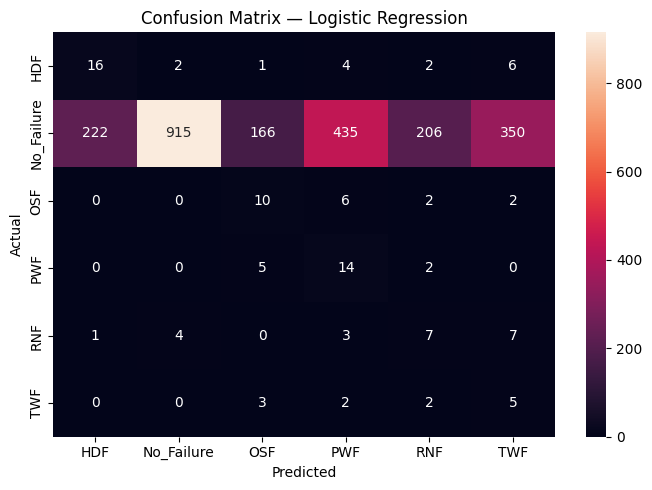

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# numeric columns must be the CLEANED names
logreg_pre = ColumnTransformer(
    transformers=[('num', StandardScaler(), num_cols_for_scale_cleaned)],
    remainder='passthrough'
)

logreg_clf = Pipeline(steps=[
    ('pre', logreg_pre),
    ('clf', LogisticRegression(
        multi_class='multinomial',
        max_iter=2000,
        class_weight='balanced',
        solver='saga',
        n_jobs=-1
    ))
])

evaluate_model("Logistic Regression", logreg_clf, X_train, y_train, X_test, y_test, le, class_names)



=== Training Random Forest ===

Random Forest — Accuracy: 0.9571 | F1_macro: 0.2447 | F1_weighted: 0.9393

              precision    recall  f1-score   support

         HDF      1.000     0.032     0.062        31
  No_Failure      0.958     0.999     0.978      2294
         OSF      1.000     0.150     0.261        20
         PWF      0.250     0.048     0.080        21
         RNF      1.000     0.045     0.087        22
         TWF      0.000     0.000     0.000        12

    accuracy                          0.957      2400
   macro avg      0.701     0.212     0.245      2400
weighted avg      0.948     0.957     0.939      2400



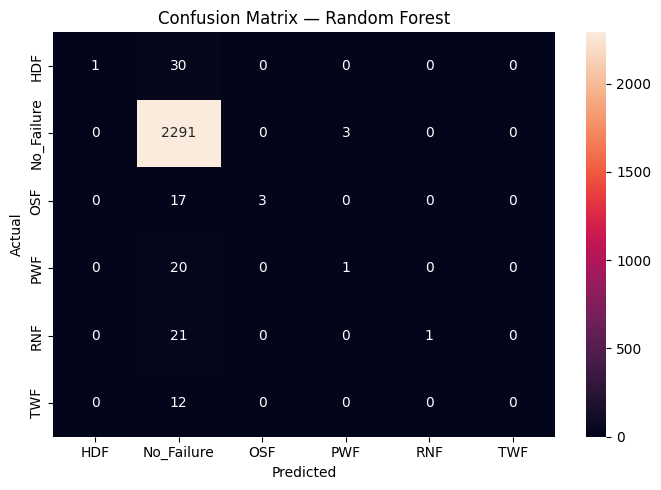

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

evaluate_model("Random Forest", rf_clf, X_train, y_train, X_test, y_test, le, class_names)



=== Training Decision Tree ===

Decision Tree — Accuracy: 0.9363 | F1_macro: 0.3303 | F1_weighted: 0.9352

              precision    recall  f1-score   support

         HDF      0.364     0.258     0.302        31
  No_Failure      0.967     0.970     0.968      2294
         OSF      0.353     0.300     0.324        20
         PWF      0.240     0.286     0.261        21
         RNF      0.048     0.045     0.047        22
         TWF      0.077     0.083     0.080        12

    accuracy                          0.936      2400
   macro avg      0.341     0.324     0.330      2400
weighted avg      0.934     0.936     0.935      2400



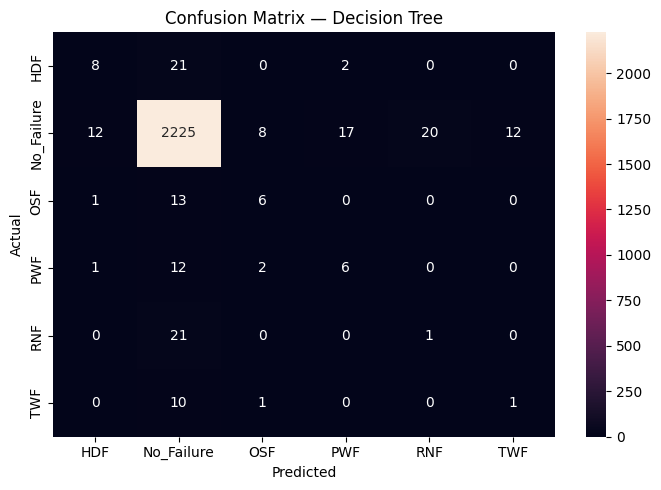

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(
    criterion='gini',         # or 'entropy' / 'log_loss'
    max_depth=None,           # try values like 8, 12 to control overfitting
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',  # handle class imbalance
    random_state=42
)

evaluate_model("Decision Tree", dt_clf, X_train, y_train, X_test, y_test, le, class_names)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

# (safe) make XGBoost-friendly column names; harmless if already cleaned
def make_xgb_safe(df_):
    return df_.rename(columns=lambda c: c.replace("[","").replace("]","")
                                   .replace("<","").replace(">","")
                                   .replace(" ","_"))

X_train_xgb = make_xgb_safe(X_train.copy())
X_test_xgb  = make_xgb_safe(X_test.copy())

def build_xgb():
    return XGBClassifier(
        objective='multi:softprob',
        num_class=len(class_names),
        eval_metric='mlogloss',
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1
    )

def evaluate_model(name, model, X_te, y_te, plot=True):
    y_pred_enc = model.predict(X_te)
    y_pred = le.inverse_transform(y_pred_enc)
    y_true = le.inverse_transform(y_te)

    acc = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro')
    f1_w   = f1_score(y_true, y_pred, average='weighted')

    print(f"\n=== {name} — Accuracy: {acc:.4f} | F1_macro: {f1_mac:.4f} | F1_weighted: {f1_w:.4f} ===\n")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0, labels=class_names))

    if plot:
        cm = confusion_matrix(y_true, y_pred, labels=class_names)
        plt.figure(figsize=(7,5))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
        plt.title(f'Confusion Matrix — {name}')
        plt.xlabel('Predicted'); plt.ylabel('Actual')
        plt.tight_layout(); plt.show()

    # Per-class recall (nice for reports)
    per_class_recall = (
        pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
          .assign(hit=lambda d: (d.y_true == d.y_pred).astype(int))
          .groupby('y_true')['hit'].mean()
          .reindex(class_names).rename('recall').round(3)
    )
    print("Per-class recall:")
    print(per_class_recall.to_string())

    return {'Model': name, 'Accuracy': acc, 'F1_macro': f1_mac, 'F1_weighted': f1_w}

results = []



=== XGBoost — Baseline — Accuracy: 0.9587 | F1_macro: 0.3579 | F1_weighted: 0.9465 ===

              precision    recall  f1-score   support

         HDF      0.875     0.226     0.359        31
  No_Failure      0.963     0.996     0.979      2294
         OSF      0.667     0.200     0.308        20
         PWF      0.200     0.095     0.129        21
         RNF      1.000     0.045     0.087        22
         TWF      1.000     0.167     0.286        12

    accuracy                          0.959      2400
   macro avg      0.784     0.288     0.358      2400
weighted avg      0.953     0.959     0.947      2400



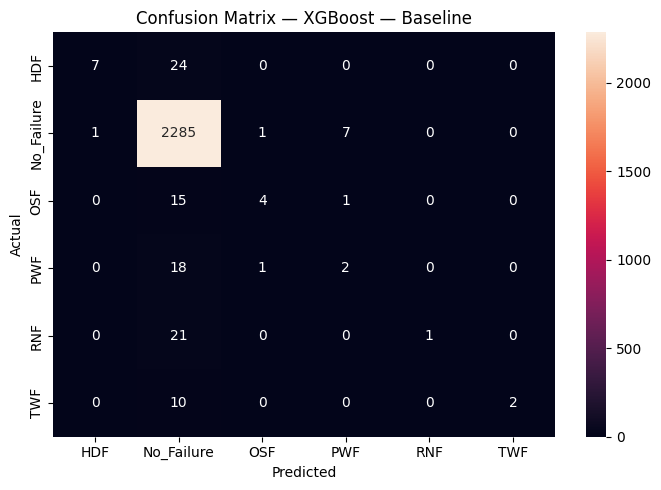

Per-class recall:
y_true
HDF           0.226
No_Failure    0.996
OSF           0.200
PWF           0.095
RNF           0.045
TWF           0.167


In [ ]:
# 1) Baseline (no rebalance)
xgb_base = build_xgb()
xgb_base.fit(X_train_xgb, y_train)
results.append(evaluate_model("XGBoost — Baseline", xgb_base, X_test_xgb, y_test))


=== XGBoost — sample_weight balanced — Accuracy: 0.9446 | F1_macro: 0.4145 | F1_weighted: 0.9440 ===

              precision    recall  f1-score   support

         HDF      0.500     0.419     0.456        31
  No_Failure      0.972     0.973     0.973      2294
         OSF      0.500     0.500     0.500        20
         PWF      0.242     0.381     0.296        21
         RNF      0.059     0.045     0.051        22
         TWF      0.286     0.167     0.211        12

    accuracy                          0.945      2400
   macro avg      0.427     0.414     0.415      2400
weighted avg      0.944     0.945     0.944      2400



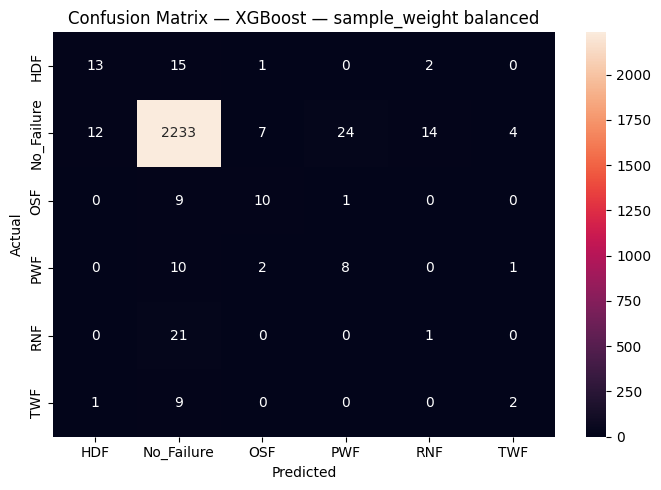

Per-class recall:
y_true
HDF           0.419
No_Failure    0.973
OSF           0.500
PWF           0.381
RNF           0.045
TWF           0.167


In [ ]:
# 2) sample_weight balanced
sw = compute_sample_weight(class_weight='balanced', y=y_train)
xgb_sw = build_xgb()
xgb_sw.fit(X_train_xgb, y_train, sample_weight=sw)
results.append(evaluate_model("XGBoost — sample_weight balanced", xgb_sw, X_test_xgb, y_test))



=== XGBoost — ROS on train — Accuracy: 0.9513 | F1_macro: 0.4179 | F1_weighted: 0.9469 ===

              precision    recall  f1-score   support

         HDF      0.706     0.387     0.500        31
  No_Failure      0.969     0.982     0.976      2294
         OSF      0.471     0.400     0.432        20
         PWF      0.304     0.333     0.318        21
         RNF      0.083     0.045     0.059        22
         TWF      0.333     0.167     0.222        12

    accuracy                          0.951      2400
   macro avg      0.478     0.386     0.418      2400
weighted avg      0.944     0.951     0.947      2400



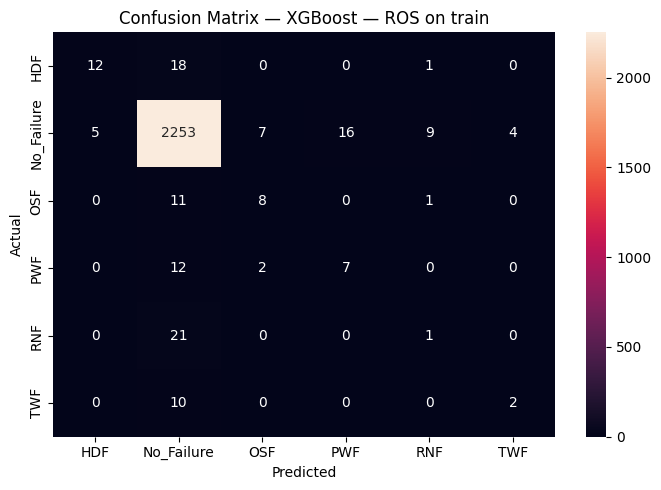

Per-class recall:
y_true
HDF           0.387
No_Failure    0.982
OSF           0.400
PWF           0.333
RNF           0.045
TWF           0.167


In [ ]:
# 3) ROS on train only
try:
    from imblearn.over_sampling import RandomOverSampler
    ros = RandomOverSampler(random_state=42)
    X_tr_ros, y_tr_ros = ros.fit_resample(X_train_xgb, y_train)

    xgb_ros = build_xgb()
    xgb_ros.fit(X_tr_ros, y_tr_ros)
    results.append(evaluate_model("XGBoost — ROS on train", xgb_ros, X_test_xgb, y_test))
except Exception as e:
    print("[INFO] RandomOverSampler unavailable:", e)


=== XGBoost — SMOTE on train — Accuracy: 0.9242 | F1_macro: 0.3676 | F1_weighted: 0.9304 ===

              precision    recall  f1-score   support

         HDF      0.324     0.387     0.353        31
  No_Failure      0.971     0.952     0.961      2294
         OSF      0.270     0.500     0.351        20
         PWF      0.273     0.429     0.333        21
         RNF      0.095     0.091     0.093        22
         TWF      0.087     0.167     0.114        12

    accuracy                          0.924      2400
   macro avg      0.337     0.421     0.368      2400
weighted avg      0.938     0.924     0.930      2400



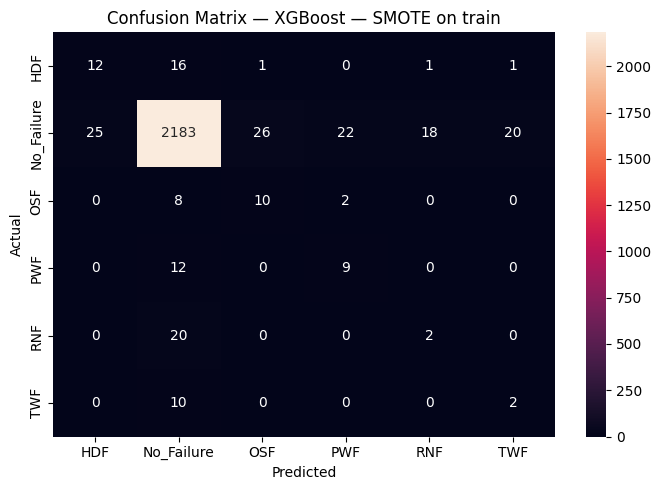

Per-class recall:
y_true
HDF           0.387
No_Failure    0.952
OSF           0.500
PWF           0.429
RNF           0.091
TWF           0.167


In [ ]:
# 4) SMOTE on train only
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_train_xgb, y_train)

    xgb_sm = build_xgb()
    xgb_sm.fit(X_tr_sm, y_tr_sm)
    results.append(evaluate_model("XGBoost — SMOTE on train", xgb_sm, X_test_xgb, y_test))
except Exception as e:
    print("[INFO] SMOTE unavailable:", e)



In [ ]:
# Summary
res_df = pd.DataFrame(results).sort_values(['F1_macro','Accuracy'], ascending=False)
print("\n=== XGBoost Variants — Summary (higher is better) ===")
print(res_df.to_string(index=False))


=== XGBoost Variants — Summary (higher is better) ===
                           Model  Accuracy  F1_macro  F1_weighted
          XGBoost — ROS on train  0.951250  0.417866     0.946946
XGBoost — sample_weight balanced  0.944583  0.414503     0.943982
        XGBoost — SMOTE on train  0.924167  0.367583     0.930417
              XGBoost — Baseline  0.958750  0.357931     0.946523


In [ ]:
import joblib

# Save the trained ROS-balanced XGBoost model
joblib.dump(xgb_ros, "final_multiclass_xgboost_ros_model.pkl")

# Save the label encoder
joblib.dump(le, "label_encoder.pkl")

# Save the feature column names
joblib.dump(list(X.columns), "feature_columns.pkl")

print("Artifacts saved: final_multiclass_xgboost_ros_model.pkl, label_encoder.pkl, feature_columns.pkl")


✅ Artifacts saved: final_multiclass_xgboost_ros_model.pkl, label_encoder.pkl, feature_columns.pkl
